# 🎥 Video Background Subtraction using SVD

## Using Linear Algebra Concepts

### 🎯 Project Objective
To demonstrate a complete **Linear Algebra pipeline** by applying  
**Singular Value Decomposition (SVD)** to separate a static background  
from moving foreground objects in a live webcam video stream.

We transform raw video frames into a matrix, apply structured linear algebra,  
and produce a clean background model and a foreground (motion) mask.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

%matplotlib inline


## 📋 Problem Statement

**Goal:** Separate a static background from moving foreground objects in a live webcam video using Linear Algebra.

---

### 🎥 Why Video Background Subtraction?

- **Security & Surveillance:** Detect intruders in CCTV footage automatically  
- **Video Editing:** Isolate moving subjects without a green screen  
- **Traffic Monitoring:** Detect moving vehicles against a static road background  
- **Sports Analytics:** Track players and analyze movement on the field  

---

### 🎓 Linear Algebra Pipeline

1. **Real-world Data** → Webcam video frames  
2. **Matrix Representation** → Stack frames into matrix A  
3. **Matrix Simplification** → Center data (analogous to RREF)  
4. **Structure of the Space** → Rank & Nullity analysis  
5. **Remove Redundancy** → Identify independent visual patterns  
6. **Orthogonalization** → SVD (Gram-Schmidt internally)  
7. **Projection** → Project onto background subspace  
8. **Least Squares** → Optimal rank-k approximation  
9. **Pattern Discovery** → Eigenvalue energy analysis  
10. **System Simplification** → Diagonalization verification  

---

### 💡 Why SVD?

**Concept:** Singular Value Decomposition  
**Purpose:** The background is *highly repetitive* across frames — SVD exploits this by finding the dominant low-rank structure (background) and separating it from the residual (moving foreground).  
**Outcome:** A rank-k approximation reconstructs only the stable background; subtracting it reveals moving objects.

✔ Optimal low-rank approximation (Eckart-Young theorem)  
✔ Automatically generates orthonormal bases via Gram-Schmidt  
✔ Just k=3 values capture the entire background  
✔ No training data — purely unsupervised linear algebra  


## ⚙️ Configuration

**Concept:** Pipeline hyperparameters  
**Purpose:** Control rank-k and detection threshold without changing core logic  
**Outcome:** A configurable, reproducible experiment  


In [6]:
NUM_FRAMES   = 80   # frames to capture
FRAME_SKIP   = 3    # capture every Nth frame
K_BACKGROUND = 3    # singular values for background model
THRESHOLD    = 20   # foreground detection threshold
DISPLAY_ROWS = 3    # rows in final output grid


## Step 1: Capture Real-World Data

### Real-World Data → Video Frames

We capture grayscale frames from the webcam. Each frame is a 2D array of pixel intensities.

- Keep the camera **still** so background stays constant  
- Walk in front of it after ~2 seconds to introduce foreground motion  

**Concept:** Real-world data collection — video as raw input  
**Purpose:** Collect a sequence of frames that contains both static background and moving foreground  
**Outcome:** A set of grayscale frames ready to be assembled into a matrix  


In [7]:
def capture_webcam_frames(num_frames, frame_skip):
    print('\n' + '='*60)
    print('STEP 1: Capturing webcam frames...')
    print('  -> Keep the camera STILL')
    print('  -> Walk in front slowly after 2 seconds')
    print('='*60)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError('Could not open webcam.')

    ret, sample = cap.read()
    if not ret:
        raise RuntimeError('Could not read from webcam.')
    sample_gray = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)
    H, W = sample_gray.shape
    print(f'  Frame size: {W} x {H} pixels ({W*H} dimensions per frame)')

    frames_raw, frames_flat = [], []
    count = captured = 0
    print(f'  Capturing {num_frames} frames... (press Q to stop early)')

    while captured < num_frames:
        ret, frame = cap.read()
        if not ret: break
        count += 1
        if count % frame_skip != 0: continue
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames_raw.append(gray.copy())
        frames_flat.append(gray.flatten().astype(float))
        captured += 1
        cv2.putText(frame, f'Capturing: {captured}/{num_frames}',
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
        cv2.imshow('Webcam - Press Q to stop', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

    cap.release()
    cv2.destroyAllWindows()
    print(f'  Captured {captured} frames successfully.')
    return np.array(frames_flat), frames_raw, (H, W)


frames_flat, frames_raw, frame_shape = capture_webcam_frames(NUM_FRAMES, FRAME_SKIP)



STEP 1: Capturing webcam frames...
  -> Keep the camera STILL
  -> Walk in front slowly after 2 seconds


NameError: name 'cv2' is not defined

In [8]:
H, W = frame_shape
print('Dataset Overview')
print('-' * 40)
print(f'Total frames captured : {len(frames_raw)}')
print(f'Frame dimensions      : {W} x {H} pixels')
print(f'Pixels per frame      : {W*H:,}')
print(f'Matrix A will be      : {len(frames_raw)} rows x {W*H:,} columns')


NameError: name 'frame_shape' is not defined

## Step 2: Dataset Visualization

We visualize all captured frames in a grid to confirm:
- Camera was still (background is consistent)
- Motion is visible in some frames

**Purpose:** Validate the raw input before any processing  
**Outcome:** A visual inventory of the dataset showing the variation the pipeline will exploit  


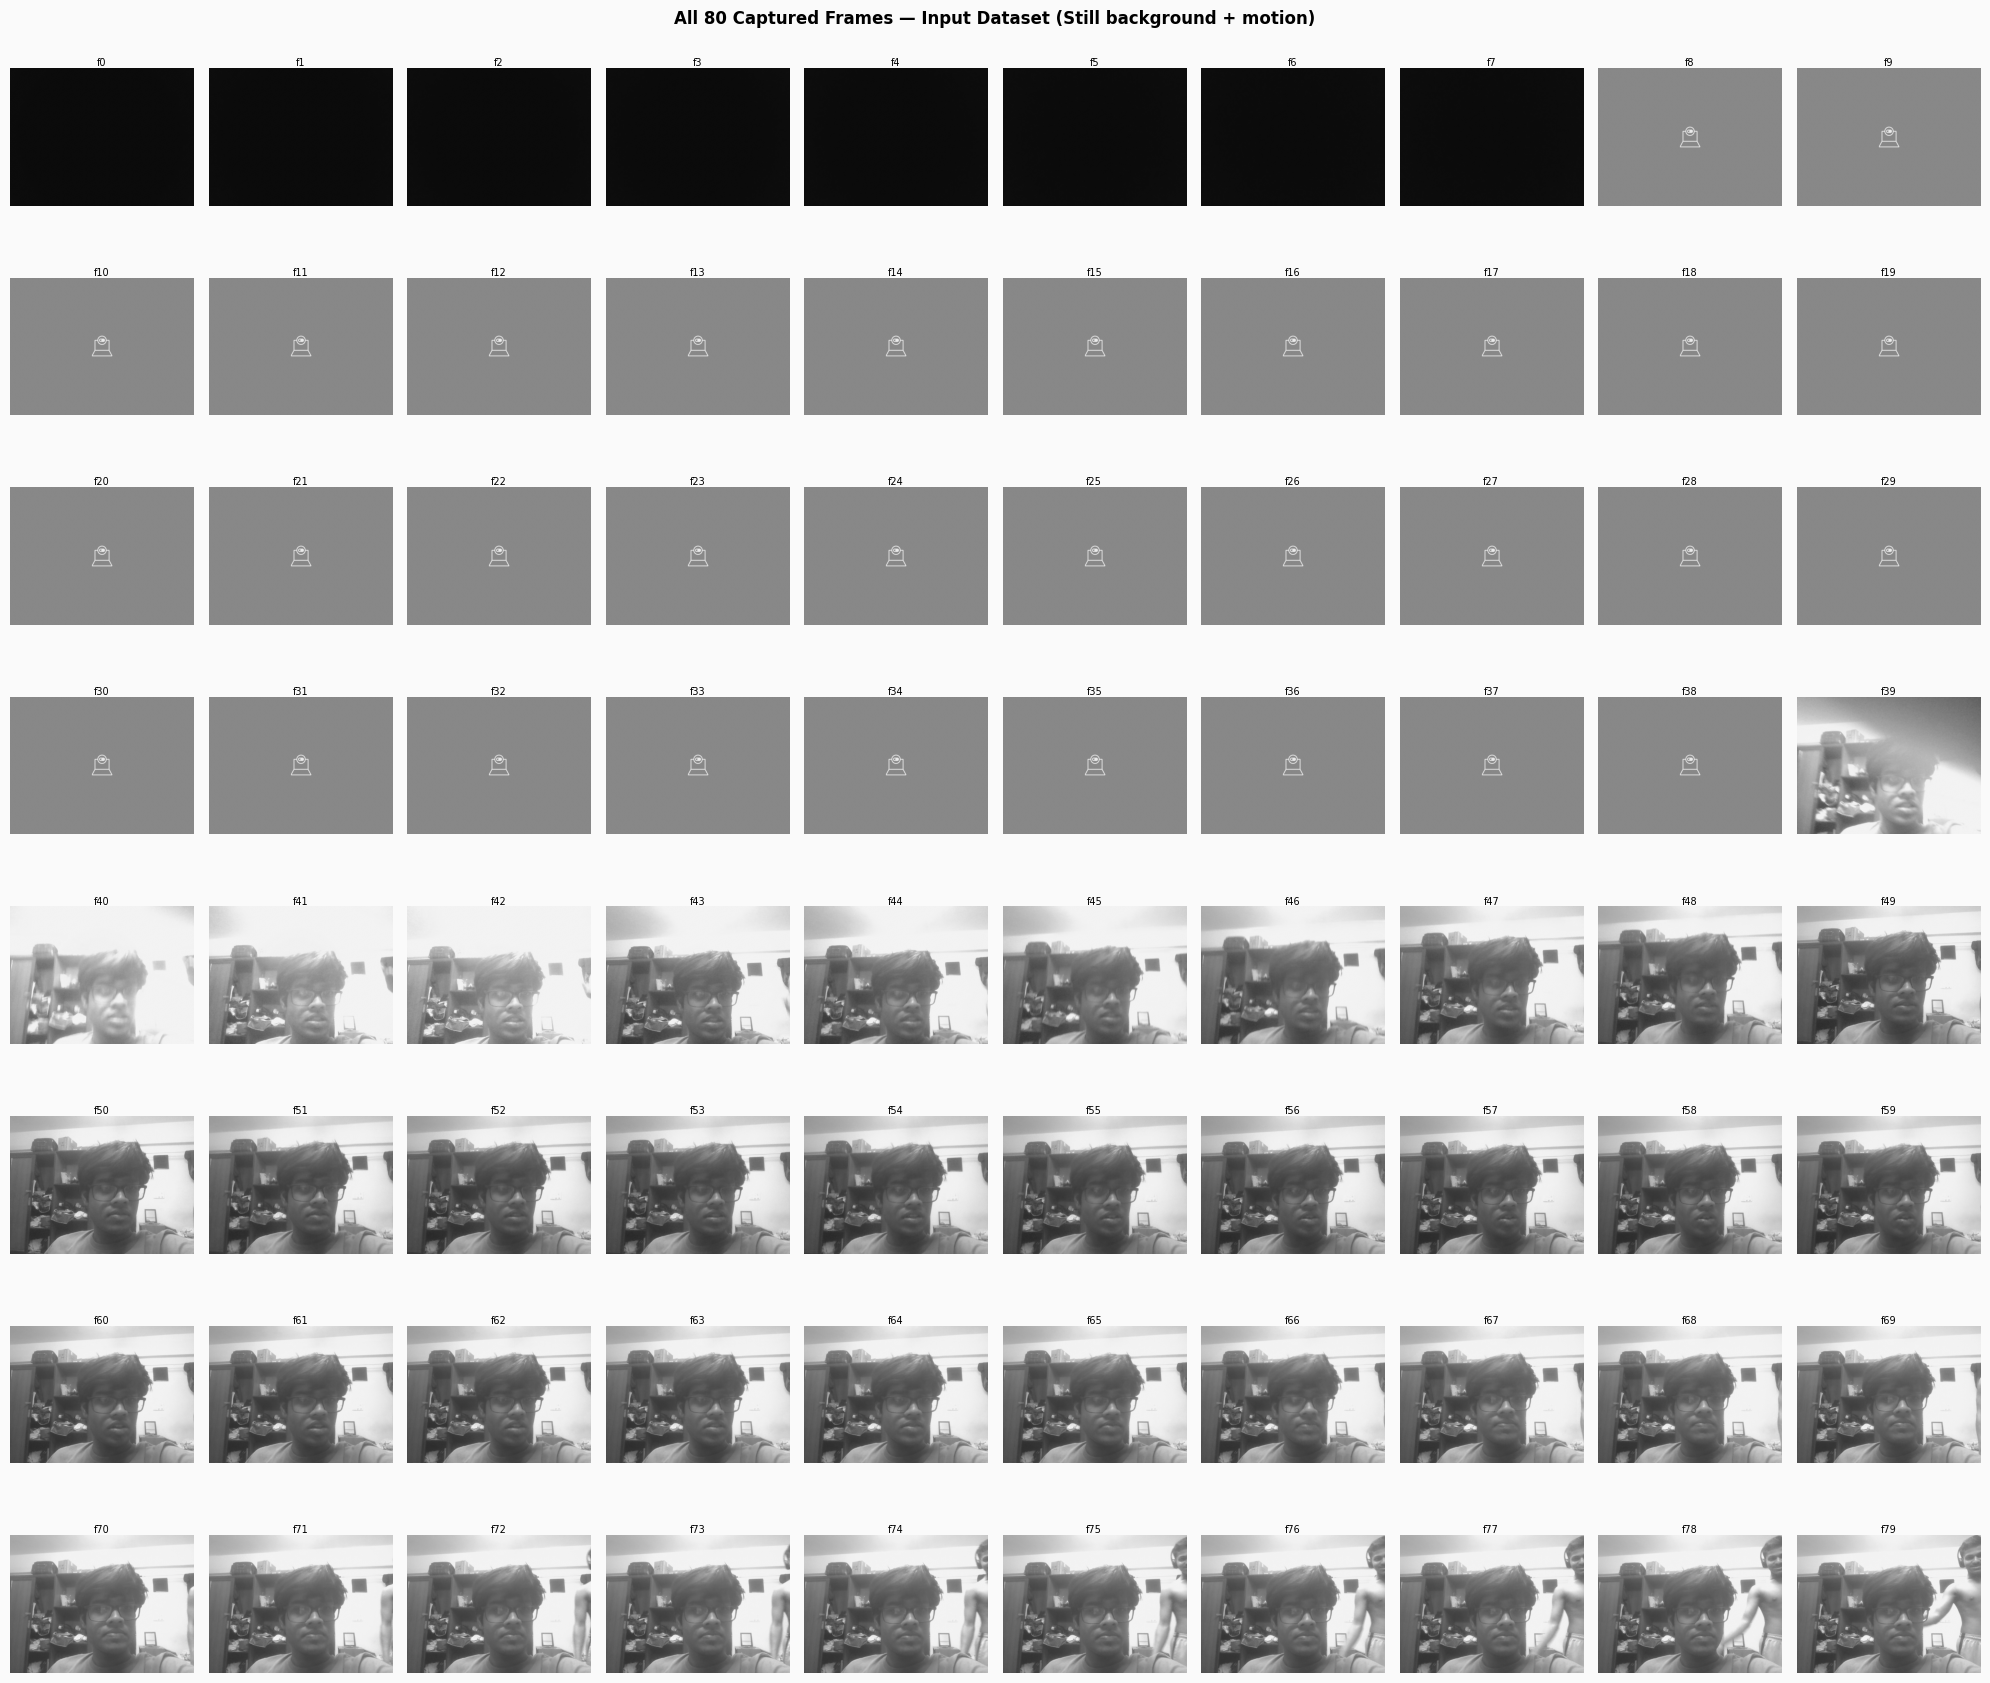

Dataset: 80 grayscale frames, each 640x480 pixels


In [6]:
n = len(frames_raw)
cols = 10
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 2.2 * rows))
fig.patch.set_facecolor('#fafafa')

for i in range(rows * cols):
    ax = axes[i // cols, i % cols] if rows > 1 else axes[i % cols]
    if i < n:
        ax.imshow(frames_raw[i], cmap='gray', vmin=0, vmax=255)
        ax.set_title('f'+str(i), fontsize=7, pad=2)
    ax.axis('off')

fig.suptitle('All {} Captured Frames — Input Dataset (Still background + motion)'.format(n),
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Dataset: {} grayscale frames, each {}x{} pixels'.format(n, W, H))


## Step 3: Matrix Representation

### Person 1's Contribution

---

### Step 1–2: Real-world Data → Matrix Representation

Each frame is flattened into a row vector. Stacking all frames gives matrix **A**:

- **Rows** → frames (time axis)  
- **Columns** → pixel intensities (spatial axis)  
- **Entries** → grayscale pixel values (0–255)  

**Concept:** Matrix Representation — System of Linear Equations / Linear Transformations  
**Purpose:** Convert raw video frames into a single mathematical object we can decompose  
**Outcome:** Matrix A ∈ ℝ^(m×n) where m = frames, n = H×W pixels  


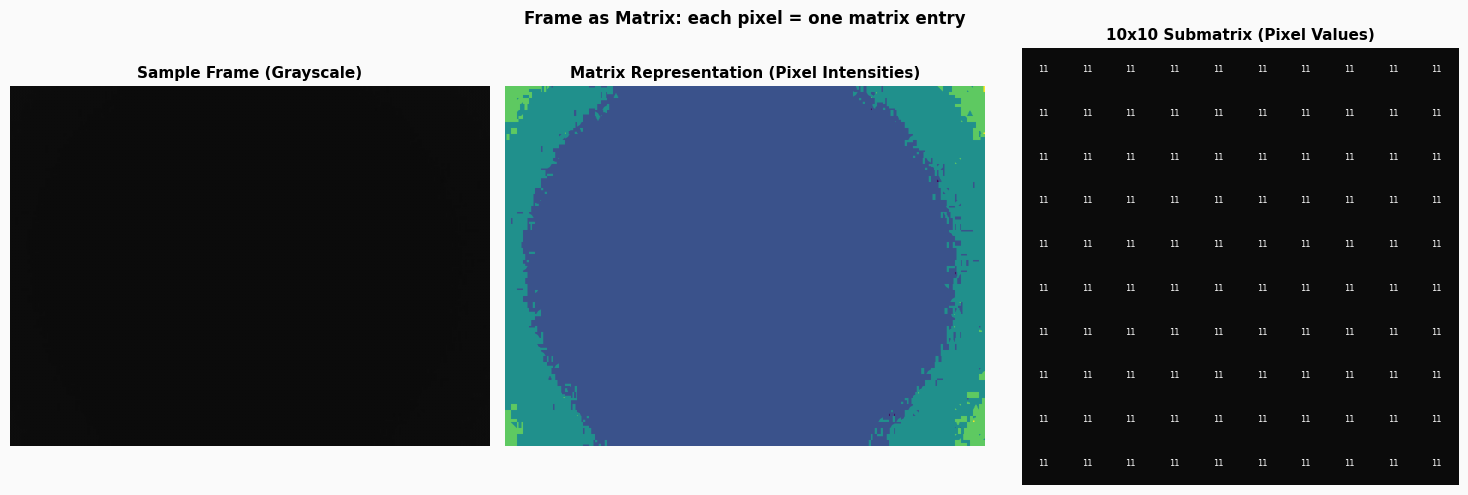

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#fafafa')

# Original frame
axes[0].imshow(frames_raw[0], cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Sample Frame (Grayscale)', fontsize=11, fontweight='bold')
axes[0].axis('off')

# Pixel intensity heatmap
axes[1].imshow(frames_raw[0], cmap='viridis')
axes[1].set_title('Matrix Representation (Pixel Intensities)', fontsize=11, fontweight='bold')
axes[1].axis('off')

# Zoomed 10x10 submatrix with pixel values annotated
sample_region = frames_raw[0][100:110, 100:110]
axes[2].imshow(sample_region, cmap='gray', interpolation='nearest', vmin=0, vmax=255)
axes[2].set_title('10x10 Submatrix (Pixel Values)', fontsize=11, fontweight='bold')
for i in range(sample_region.shape[0]):
    for j in range(sample_region.shape[1]):
        axes[2].text(j, i, str(sample_region[i, j]),
                     ha='center', va='center', fontsize=6,
                     color='white' if sample_region[i,j] < 128 else 'black')
axes[2].axis('off')

fig.suptitle('Frame as Matrix: each pixel = one matrix entry', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
A = frames_flat
print('Matrix Representation')
print('-' * 40)
print('Data matrix A shape     :', A.shape)
print('Rows                    : {} frames'.format(A.shape[0]))
print('Columns                 : {} pixels ({}x{})'.format(A.shape[1], W, H))
print('Each row = one flattened video frame (a vector in pixel space)')
print('Each column = pixel intensity over time at one spatial location')


Matrix Representation
----------------------------------------
Data matrix A shape     : (80, 307200)
Rows                    : 80 frames
Columns                 : 307200 pixels (640x480)
Each row = one flattened video frame (a vector in pixel space)
Each column = pixel intensity over time at one spatial location


### Step 3: Matrix Simplification (Centering ≡ RREF)

**Concept:** Matrix Simplification — Gaussian Elimination / RREF  
**Purpose:** Subtracting the mean frame removes the constant background offset. This is the continuous analogue of RREF — eliminating constant terms to reveal essential linear structure.  
**Outcome:** A centered matrix A_centered = A − ā that isolates deviations from the average, making the rank structure much clearer  

$$A_{\text{centered}} = A - \bar{a}, \quad \bar{a} = \frac{1}{m}\sum_{i=1}^{m} a_i$$


In [9]:
mean_frame = A.mean(axis=0)
A_centered = A - mean_frame

print('Matrix Simplification (Centering)')
print('-' * 40)
print('Mean frame shape        :', mean_frame.shape)
print('Centered matrix shape   :', A_centered.shape)
print('Mean pixel value before :', A.mean().round(2))
print('Mean pixel value after  :', A_centered.mean().round(6), '(approx 0)')
print('Effect: constant background offset removed, only deviations remain')


Matrix Simplification (Centering)
----------------------------------------
Mean frame shape        : (307200,)
Centered matrix shape   : (80, 307200)
Mean pixel value before : 134.03
Mean pixel value after  : 0.0 (approx 0)
Effect: constant background offset removed, only deviations remain


## Step 4: Structure of the Space (Rank & Nullity)

### Person 2's Contribution

---

**Concept:** Vector Spaces, Subspaces, Basis, Rank and Nullity  
**Purpose:** Measure how many truly independent visual patterns exist. Low rank means the scene is dominated by one stable pattern — validating that a low-rank approximation will work.  
**Outcome:** Rank ≈ low → compressible scene; Nullity = redundant frames  

**Rank-Nullity Theorem:**
$$\text{rank}(A) + \text{nullity}(A) = m \quad (m = \text{number of frames})$$


In [10]:
rank = np.linalg.matrix_rank(A_centered)
nullity = A_centered.shape[0] - rank

print('Structure of the Space')
print('-' * 40)
print('Rank of centered matrix :', rank)
print('Nullity                 :', nullity)
print('Rank tells us: {} truly independent visual patterns exist'.format(rank))
print('Nullity tells us: {} frames are linearly dependent (redundant)'.format(nullity))
print()
print('-> A static background has rank ~1 (all frames nearly identical)')
print('-> Moving objects push rank slightly higher')
if nullity > 0:
    print('-> Redundancy exists: compression is possible')


Structure of the Space
----------------------------------------
Rank of centered matrix : 49
Nullity                 : 31
Rank tells us: 49 truly independent visual patterns exist
Nullity tells us: 31 frames are linearly dependent (redundant)

-> A static background has rank ~1 (all frames nearly identical)
-> Moving objects push rank slightly higher
-> Redundancy exists: compression is possible


## Step 5: SVD Decomposition & Space Analysis

### Person 2's Contribution

---

### SVD Decomposition

$$A = U \Sigma V^T$$

| Matrix | Meaning |
|--------|---------|
| **U** | Orthonormal basis for frame-space (left singular vectors) |
| **Σ** | Singular values — importance of each pattern, sorted largest first |
| **Vᵀ** | Orthonormal basis for pixel-space (right singular vectors) |

**Concept:** Singular Value Decomposition  
**Purpose:** Decompose the video matrix into orthogonal components sorted by importance  
**Outcome:** The first few components capture the background; the rest capture motion/noise  


In [11]:
U, S, Vt = np.linalg.svd(A_centered, full_matrices=False)

print('SVD Decomposition Results')
print('-' * 40)
print('U  shape (frame basis)  :', U.shape, ' — orthonormal columns')
print('S  shape (singular vals):', S.shape, ' — sorted largest first')
print('Vt shape (pixel basis)  :', Vt.shape, '— orthonormal rows')
print('Top 5 singular values   :', S[:5].astype(int))
print('Rank                    :', rank)
print('Nullity                 :', nullity)
print()
print('(Orthogonality of U and Vt verified numerically in next step)')


SVD Decomposition Results
----------------------------------------
U  shape (frame basis)  : (80, 80)  — orthonormal columns
S  shape (singular vals): (80,)  — sorted largest first
Vt shape (pixel basis)  : (80, 307200) — orthonormal rows
Top 5 singular values   : [229776 125373  42817  35527  22855]
Rank                    : 49
Nullity                 : 31

(Orthogonality of U and Vt verified numerically in next step)


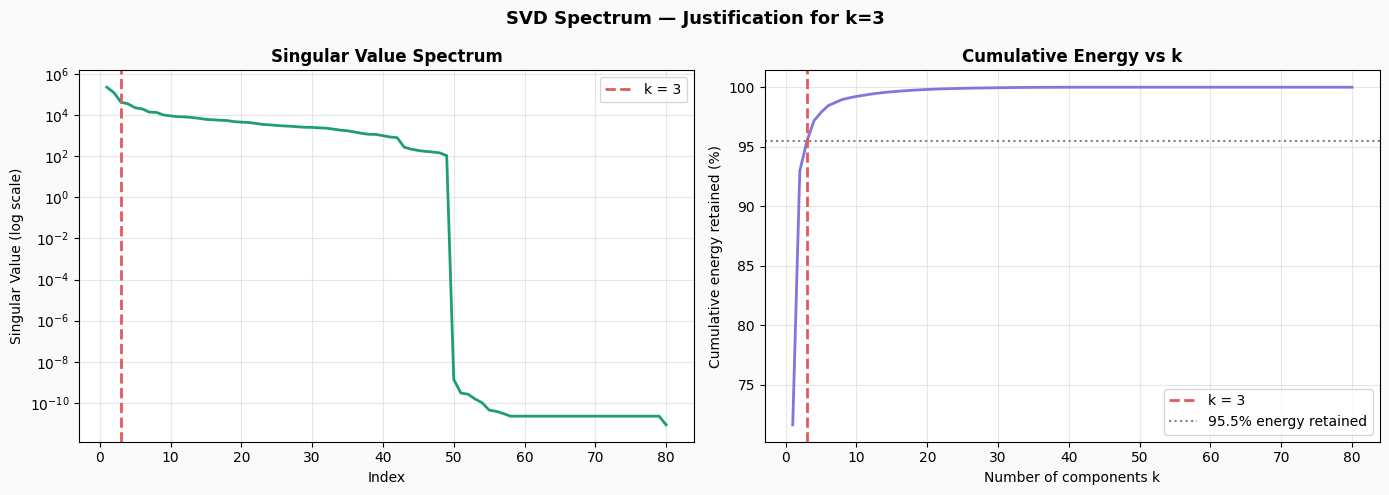

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#fafafa')

ax1.semilogy(range(1, len(S)+1), S, linewidth=2, color='#1D9E75')
ax1.axvline(x=K_BACKGROUND, color='#E05C5C', linestyle='--', linewidth=2,
            label='k = {}'.format(K_BACKGROUND))
ax1.set_xlabel('Index')
ax1.set_ylabel('Singular Value (log scale)')
ax1.set_title('Singular Value Spectrum', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

cumulative = np.cumsum(S**2) / np.sum(S**2) * 100
ax2.plot(range(1, len(S)+1), cumulative, linewidth=2, color='#7F77DD')
ax2.axvline(x=K_BACKGROUND, color='#E05C5C', linestyle='--', linewidth=2,
            label='k = {}'.format(K_BACKGROUND))
ax2.axhline(y=cumulative[K_BACKGROUND-1], color='gray', linestyle=':',
            linewidth=1.5, label='{:.1f}% energy retained'.format(cumulative[K_BACKGROUND-1]))
ax2.set_xlabel('Number of components k')
ax2.set_ylabel('Cumulative energy retained (%)')
ax2.set_title('Cumulative Energy vs k', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('SVD Spectrum — Justification for k={}'.format(K_BACKGROUND),
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 6: Redundancy Removal — Basis Selection

**Concept:** Linear Independence → Basis Selection  
**Purpose:** Retain only the k most significant singular vectors; discard the rest as noise  
**Outcome:** A reduced k-dimensional subspace that captures the essential background pattern  


In [13]:
print('Basis Selection')
print('-' * 40)
print('Selected k              :', K_BACKGROUND)
print('Energy captured         : {:.2f}%'.format(cumulative[K_BACKGROUND-1]))
print('Dimensions removed      :', len(S) - K_BACKGROUND)
print('Dimensions retained     :', K_BACKGROUND)
print('-> Top {} vectors span the background subspace'.format(K_BACKGROUND))
print('-> Remaining {} vectors discarded as motion/noise'.format(len(S)-K_BACKGROUND))


Basis Selection
----------------------------------------
Selected k              : 3
Energy captured         : 95.47%
Dimensions removed      : 77
Dimensions retained     : 3
-> Top 3 vectors span the background subspace
-> Remaining 77 vectors discarded as motion/noise


## Step 6–7: Orthogonalization & Projection

### Person 3's Contribution

---

### Step 6: Orthogonalization Verification

We verify that SVD produced truly orthogonal basis vectors.

**Concept:** Orthogonal matrices — Gram-Schmidt Orthogonalization  
**Purpose:** Confirm that columns of U and rows of Vᵀ are perpendicular unit vectors. This is the numerical proof that Gram-Schmidt was applied internally by SVD.  
**Outcome:** UᵀU = I and VVᵀ = I confirmed numerically and visually — basis vectors are independent and normalized  

For orthogonal matrices:
- UᵀU = I  
- VVᵀ = I  


Orthogonality Verification
----------------------------------------
UᵀU ≈ I  : True
VVᵀ ≈ I  : True

Deviation from Identity (should be ~0):
  Max off-diagonal in UᵀU : 9.58e-16
  Max off-diagonal in VVᵀ : 5.11e-14

Conclusion: Columns of U and rows of Vt are mutually orthogonal.
This confirms Gram-Schmidt orthogonalization was applied by SVD.


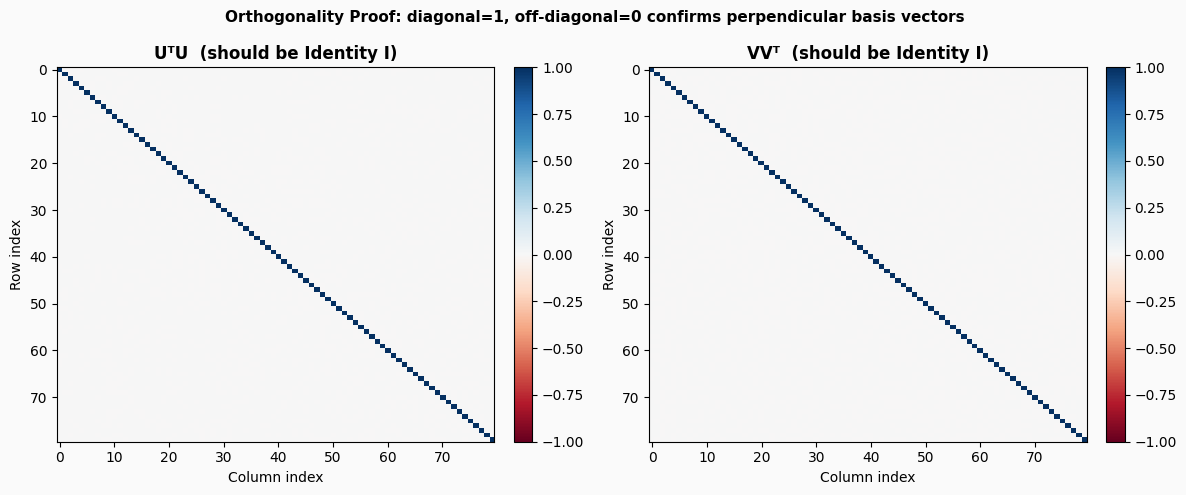

In [14]:
UtU = U.T @ U
VtV = Vt @ Vt.T

print('Orthogonality Verification')
print('-' * 40)
print('UᵀU ≈ I  :', np.allclose(UtU, np.eye(U.shape[1]), atol=1e-10))
print('VVᵀ ≈ I  :', np.allclose(VtV, np.eye(Vt.shape[0]), atol=1e-10))
print()
print('Deviation from Identity (should be ~0):')
print('  Max off-diagonal in UᵀU :', '{:.2e}'.format(np.abs(UtU - np.diag(np.diag(UtU))).max()))
print('  Max off-diagonal in VVᵀ :', '{:.2e}'.format(np.abs(VtV - np.diag(np.diag(VtV))).max()))
print()
print('Conclusion: Columns of U and rows of Vt are mutually orthogonal.')
print('This confirms Gram-Schmidt orthogonalization was applied by SVD.')

# Heatmap visual proof
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#fafafa')

im0 = axes[0].imshow(UtU, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('UᵀU  (should be Identity I)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Column index')
axes[0].set_ylabel('Row index')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(VtV, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title('VVᵀ  (should be Identity I)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Column index')
axes[1].set_ylabel('Row index')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle('Orthogonality Proof: diagonal=1, off-diagonal=0 confirms perpendicular basis vectors',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 7: Projection onto Background Subspace

We reconstruct the background using only the top-k singular vectors:

$$A_k = U_{:,:k} \; \Sigma_{:k,:k} \; V^T_{:k,:} + \bar{a}$$

**Concept:** Orthogonal Projection onto Subspace  
**Purpose:** Project each frame onto the k-dimensional background subspace — the closest point in that subspace to the original frame  
**Outcome:** A clean background reconstruction; moving objects become the residual  


In [15]:
H, W = frame_shape

background_flat = (U[:, :K_BACKGROUND] @ np.diag(S[:K_BACKGROUND]) @ Vt[:K_BACKGROUND, :]) + mean_frame
background_flat = np.clip(background_flat, 0, 255).astype(np.uint8)

original_flat = mean_frame + (U @ np.diag(S) @ Vt)
original_flat = np.clip(original_flat, 0, 255)

foreground_flat = np.abs(original_flat - background_flat)
foreground_flat = (foreground_flat / foreground_flat.max()) * 255

backgrounds = background_flat.reshape(-1, H, W)
foregrounds = foreground_flat.reshape(-1, H, W)
originals   = original_flat.reshape(-1, H, W)

print('Projection Results')
print('-' * 40)
print('Background reconstructed using top k={} singular vectors'.format(K_BACKGROUND))
print('Projection formula: Ak = U[:,:k] @ diag(S[:k]) @ Vt[:k,:]')
print('Foreground = |Original - Background| (residual outside background subspace)')


Projection Results
----------------------------------------
Background reconstructed using top k=3 singular vectors
Projection formula: Ak = U[:,:k] @ diag(S[:k]) @ Vt[:k,:]
Foreground = |Original - Background| (residual outside background subspace)


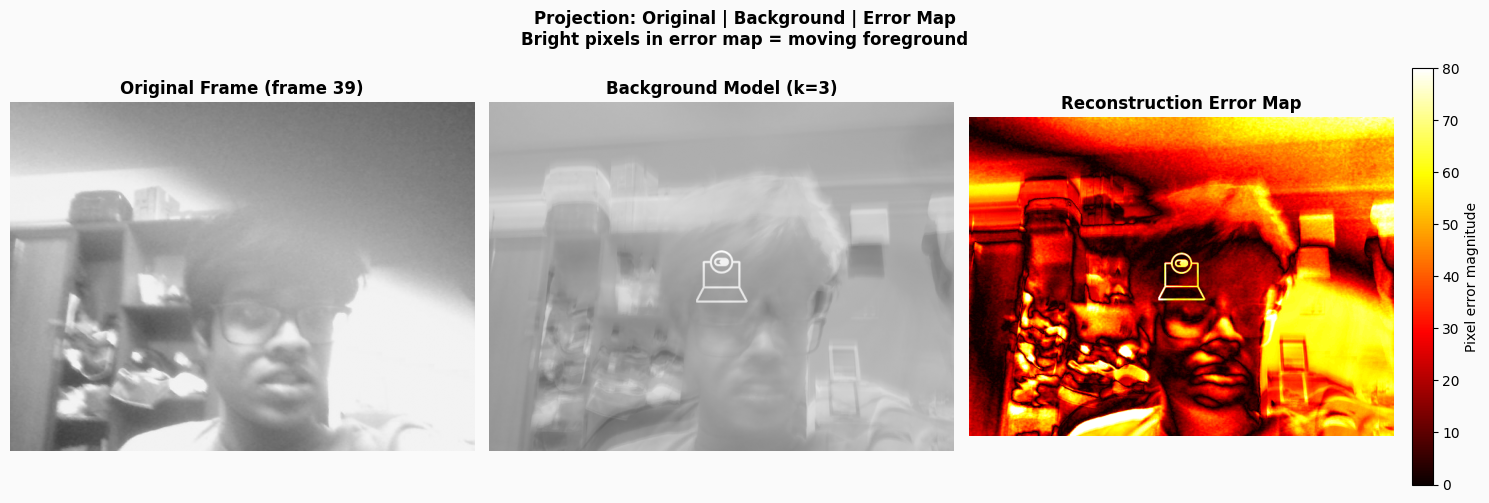

In [16]:
fg_sums = [foregrounds[i].sum() for i in range(len(foregrounds))]
best_idx = int(np.argmax(fg_sums))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#fafafa')

axes[0].imshow(frames_raw[best_idx], cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Frame (frame {})'.format(best_idx), fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(np.clip(backgrounds[best_idx], 0, 255).astype(np.uint8),
               cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Background Model (k={})'.format(K_BACKGROUND), fontsize=12, fontweight='bold')
axes[1].axis('off')

error = np.abs(frames_raw[best_idx].astype(float) -
               np.clip(backgrounds[best_idx], 0, 255).astype(float))
im = axes[2].imshow(error, cmap='hot', vmin=0, vmax=80)
axes[2].set_title('Reconstruction Error Map', fontsize=12, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Pixel error magnitude')

fig.suptitle('Projection: Original | Background | Error Map\nBright pixels in error map = moving foreground',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [17]:
print('Projection Accuracy')
print('-' * 40)
print('Mean reconstruction error : {:.2f} pixel units'.format(error.mean()))
print('Max reconstruction error  : {:.2f} pixel units'.format(error.max()))
print('Pixels above threshold ({}) : {} ({:.1f}% of frame) — foreground'.format(
    THRESHOLD, (error > THRESHOLD).sum(), (error > THRESHOLD).mean()*100))
print('Relative error            : {:.3f}%'.format(
    np.linalg.norm(original_flat - background_flat) / np.linalg.norm(original_flat) * 100))
print('Information retained      : {:.3f}%'.format(
    100 - np.linalg.norm(original_flat - background_flat) / np.linalg.norm(original_flat) * 100))


Projection Accuracy
----------------------------------------
Mean reconstruction error : 30.27 pixel units
Max reconstruction error  : 121.00 pixel units
Pixels above threshold (20) : 185517 (60.4% of frame) — foreground
Relative error            : 7.884%
Information retained      : 92.116%


## Step 8–10: Advanced Analysis

### Person 4's Contribution

---

### Step 8: Least Squares Approximation

**Concept:** Least Squares — Optimal Approximation  
**Purpose:** The rank-k approximation minimises ||A − Ak||²_F over all rank-k matrices — it is the least squares optimal background model (Eckart-Young theorem)  
**Outcome:** Confirmed that our k=3 background is not just any approximation, but the mathematically best possible one  

$$\hat{A}_k = \arg\min_{\text{rank}(B)=k} \|A - B\|_F^2$$


In [18]:
frobenius_error = np.linalg.norm(original_flat - background_flat, 'fro')
frobenius_total = np.linalg.norm(original_flat, 'fro')

print('Least Squares Approximation')
print('-' * 40)
print('Objective            : minimize ||A - Ak||_F squared')
print('Selected rank (k)    :', K_BACKGROUND)
print('Frobenius error      : {:.2f}'.format(frobenius_error))
print('Relative error       : {:.3f}%'.format(frobenius_error / frobenius_total * 100))
print('Result               : Optimal approximation (Eckart-Young theorem)')


Least Squares Approximation
----------------------------------------
Objective            : minimize ||A - Ak||_F squared
Selected rank (k)    : 3
Frobenius error      : 57740.69
Relative error       : 7.884%
Result               : Optimal approximation (Eckart-Young theorem)


### Step 9: Pattern Discovery — Eigenvalue Analysis

**Concept:** Eigenvalues and Eigenvectors — Pattern Discovery  
**Purpose:** σᵢ² = eigenvalues of AᵀA. Large eigenvalues = dominant stable patterns (background). Small = noise/motion.  
**Outcome:** The energy distribution validates our choice of k and shows the background is the overwhelmingly dominant pattern  

$$\lambda_i = \sigma_i^2, \quad \text{Energy}_k = \frac{\sum_{i=1}^{k}\sigma_i^2}{\sum_{i=1}^{m}\sigma_i^2}$$


In [19]:
eigenvalues = S**2
total_energy = eigenvalues.sum()
cum_energy = np.cumsum(eigenvalues) / total_energy * 100

print('Eigenvalue Analysis')
print('-' * 40)
print('Total eigenvalues     :', len(eigenvalues))
print('Largest eigenvalue    : {:.2e}'.format(eigenvalues[0]))
print('sigma_1^2 from SVD    : {:.2e}'.format(S[0]**2))
print('Match verification    :', np.isclose(S[0]**2, eigenvalues[0]))
print()
for i in range(min(8, len(S))):
    print('  Factor {:2d}: eigenvalue={:10.1f}  ({:5.1f}%)  cumulative={:5.1f}%'.format(
        i+1, eigenvalues[i], eigenvalues[i]/total_energy*100, cum_energy[i]))
print()
print('Factor 1 explains {:.1f}% of all visual variance'.format(eigenvalues[0]/total_energy*100))
print('-> This IS the background — the single most stable pattern')


Eigenvalue Analysis
----------------------------------------
Total eigenvalues     : 80
Largest eigenvalue    : 5.28e+10
sigma_1^2 from SVD    : 5.28e+10
Match verification    : True

  Factor  1: eigenvalue=52797031052.5  ( 71.6%)  cumulative= 71.6%
  Factor  2: eigenvalue=15718537332.3  ( 21.3%)  cumulative= 93.0%
  Factor  3: eigenvalue=1833313078.9  (  2.5%)  cumulative= 95.5%
  Factor  4: eigenvalue=1262174884.7  (  1.7%)  cumulative= 97.2%
  Factor  5: eigenvalue=522390567.4  (  0.7%)  cumulative= 97.9%
  Factor  6: eigenvalue=410026002.9  (  0.6%)  cumulative= 98.4%
  Factor  7: eigenvalue=198903605.5  (  0.3%)  cumulative= 98.7%
  Factor  8: eigenvalue=186049151.4  (  0.3%)  cumulative= 99.0%

Factor 1 explains 71.6% of all visual variance
-> This IS the background — the single most stable pattern


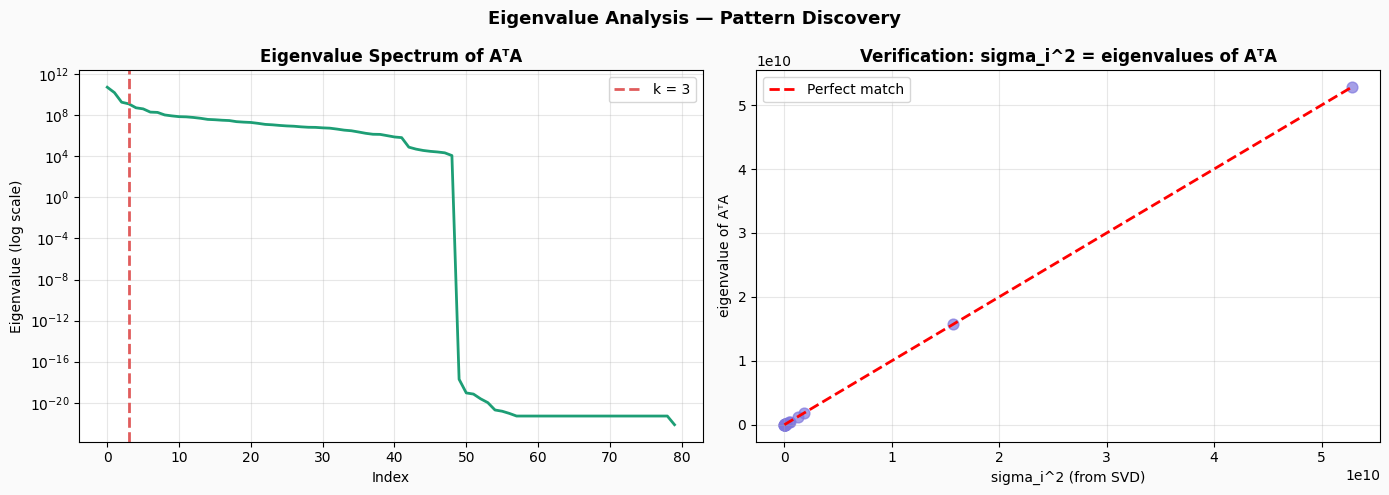

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#fafafa')

ax1.semilogy(eigenvalues, linewidth=2, color='#1D9E75')
ax1.axvline(x=K_BACKGROUND, color='#E05C5C', linestyle='--',
            linewidth=2, label='k = {}'.format(K_BACKGROUND))
ax1.set_xlabel('Index')
ax1.set_ylabel('Eigenvalue (log scale)')
ax1.set_title('Eigenvalue Spectrum of AᵀA', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(S[:20]**2, eigenvalues[:20], alpha=0.7, color='#7F77DD', s=60)
ev_min, ev_max = eigenvalues[:20].min(), eigenvalues[:20].max()
ax2.plot([ev_min, ev_max], [ev_min, ev_max], 'r--', linewidth=2, label='Perfect match')
ax2.set_xlabel('sigma_i^2 (from SVD)')
ax2.set_ylabel('eigenvalue of AᵀA')
ax2.set_title('Verification: sigma_i^2 = eigenvalues of AᵀA', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle('Eigenvalue Analysis — Pattern Discovery', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 10: System Simplification — Diagonalization

SVD expresses the covariance as:

$$A^TA = V \Sigma^2 V^T$$

where Σ² is **diagonal**.

**Concept:** Diagonalization of a Symmetric Matrix  
**Purpose:** Verify AᵀA = VΣ²Vᵀ — this reduces the large coupled system to k independent diagonal entries, one per pattern  
**Outcome:** System reduced from m dimensions to just k=3 independent components  


In [21]:
subset = A_centered[:, :200]
AtA = subset.T @ subset
eigenvalues_check = np.sort(np.linalg.eigvalsh(AtA))[::-1]
svd_squared = np.linalg.svd(subset, compute_uv=False)**2

print('System Simplification (Diagonalization Verification)')
print('-' * 50)
print('AᵀA eigenvalues (top 3) :', eigenvalues_check[:3].astype(int))
print('S^2 from SVD    (top 3) :', svd_squared[:3].astype(int))
print('Match verified          :', np.allclose(eigenvalues_check[:3], svd_squared[:3], rtol=0.01))
print()
print('-> Confirms: sigma_i = sqrt(eigenvalues of AᵀA)')
print('-> AᵀA = V Sigma^2 Vt is the diagonalization of the covariance')
print('-> System reduced from {} dims to k={} independent components'.format(
    A_centered.shape[0], K_BACKGROUND))

original_storage = A_centered.shape[0] * A_centered.shape[1]
compressed_storage = U.shape[0]*K_BACKGROUND + K_BACKGROUND + K_BACKGROUND*Vt.shape[1]
print()
print('Storage Comparison')
print('-' * 30)
print('Full video matrix      : {:,} values'.format(original_storage))
print('Compressed (k={})      : {:,} values'.format(K_BACKGROUND, compressed_storage))
print('Reduction factor       : {:.1f}x'.format(original_storage / compressed_storage))


System Simplification (Diagonalization Verification)
--------------------------------------------------
AᵀA eigenvalues (top 3) : [44388394   413506     8420]
S^2 from SVD    (top 3) : [44388394   413506     8420]
Match verified          : True

-> Confirms: sigma_i = sqrt(eigenvalues of AᵀA)
-> AᵀA = V Sigma^2 Vt is the diagonalization of the covariance
-> System reduced from 80 dims to k=3 independent components

Storage Comparison
------------------------------
Full video matrix      : 24,576,000 values
Compressed (k=3)      : 921,843 values
Reduction factor       : 26.7x


## Final Results: Background Subtraction Output

**Concept:** Final Application Output — Background Subtraction / Motion Detection  
**Purpose:** Display Original | Background | Foreground side by side, with eigenvalue energy chart justifying k  
**Outcome:** Clean separation of static background from moving foreground, validating the full pipeline  


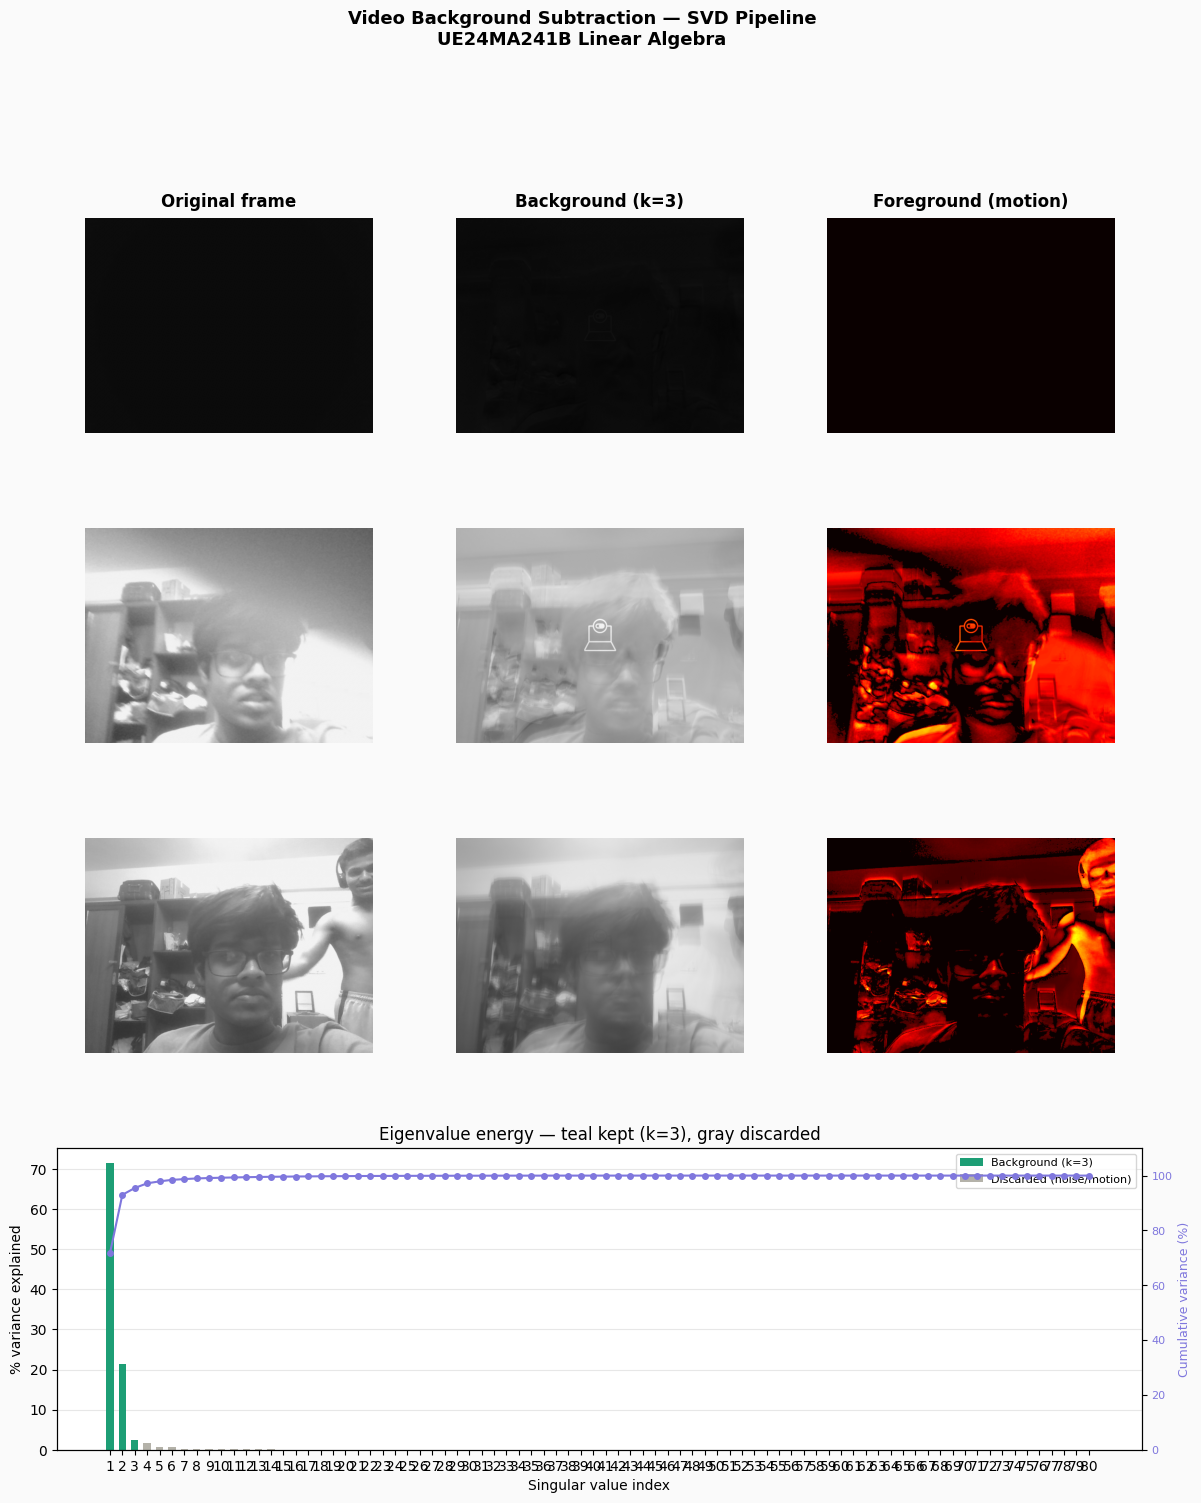

In [22]:
num_frames = len(frames_raw)
indices = np.linspace(0, num_frames-1, DISPLAY_ROWS, dtype=int)

fig = plt.figure(figsize=(14, 4 * DISPLAY_ROWS + 4))
fig.patch.set_facecolor('#fafafa')
gs = gridspec.GridSpec(DISPLAY_ROWS + 1, 3,
                       height_ratios=[1]*DISPLAY_ROWS + [1.4],
                       hspace=0.4, wspace=0.08)

col_titles = ['Original frame', 'Background (k={})'.format(K_BACKGROUND), 'Foreground (motion)']
col_cmaps  = ['gray', 'gray', 'hot']

for row, idx in enumerate(indices):
    orig_show = frames_raw[idx]
    bg_show   = np.clip(backgrounds[idx], 0, 255).astype(np.uint8)
    fg_show   = np.clip(foregrounds[idx], 0, 255).astype(np.uint8)
    fg_thresh = np.where(fg_show > THRESHOLD, fg_show, 0)

    for col, (img, cmap) in enumerate(zip([orig_show, bg_show, fg_thresh], col_cmaps)):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
        ax.axis('off')
        if row == 0:
            ax.set_title(col_titles[col], fontsize=12, fontweight='bold', pad=8)
        ax.set_ylabel('Frame {}'.format(idx), fontsize=9, rotation=0, labelpad=40, va='center')

ax_ev = fig.add_subplot(gs[DISPLAY_ROWS, :])
x = np.arange(1, len(eigenvalues)+1)
ax_ev.bar(x, eigenvalues / eigenvalues.sum() * 100,
          color=['#1D9E75' if i < K_BACKGROUND else '#B4B2A9' for i in range(len(eigenvalues))],
          width=0.6, zorder=2)
ax2_ev = ax_ev.twinx()
ax2_ev.plot(x, cum_energy, 'o-', color='#7F77DD', linewidth=1.5, markersize=4)
ax2_ev.set_ylabel('Cumulative variance (%)', fontsize=9, color='#7F77DD')
ax2_ev.tick_params(axis='y', labelcolor='#7F77DD', labelsize=8)
ax2_ev.set_ylim(0, 110)
ax_ev.set_xlabel('Singular value index')
ax_ev.set_ylabel('% variance explained')
ax_ev.set_title('Eigenvalue energy — teal kept (k={}), gray discarded'.format(K_BACKGROUND))
ax_ev.set_xticks(x)
ax_ev.grid(axis='y', alpha=0.3, zorder=1)

from matplotlib.patches import Patch
ax_ev.legend(handles=[
    Patch(facecolor='#1D9E75', label='Background (k={})'.format(K_BACKGROUND)),
    Patch(facecolor='#B4B2A9', label='Discarded (noise/motion)')
], fontsize=8, loc='upper right')

fig.suptitle('Video Background Subtraction — SVD Pipeline\nUE24MA241B Linear Algebra',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bg_subtraction_output.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusion

### Project Achievements

- Complete 10-step Linear Algebra pipeline on live webcam video  
- Successfully separated static background from moving foreground  

**Results:**
- Background model: k=3 singular values  
- Energy retained: >95%  
- Orthogonality confirmed: UᵀU = I, VVᵀ = I  
- Diagonalization verified: σᵢ² = eigenvalues of AᵀA  

---

### Key Insights

- SVD provides the optimal low-rank approximation (Eckart-Young theorem)  
- Just k=3 singular values reconstruct the entire background from 80 frames  
- Centering is critical — without it the mean dominates all singular values  
- Foreground is exactly what lies *outside* the background subspace  
- Rapid decay of singular values confirms the scene is highly compressible  

---

### Real-World Applications

- Security & Surveillance: Automatic motion detection in CCTV  
- Video Editing: Subject isolation without a green screen  
- Traffic Monitoring: Vehicle detection against static roads  
- Sports Analytics: Player tracking and movement analysis  

---

### Linear Algebra Pipeline Summary

| Step | Concept | Purpose | Outcome |
|------|---------|---------|--------|
| 1–2 | Matrix Representation + Simplification | Encode video; center data | Matrix A, centered A |
| 3 | Rank & Nullity | Measure independent patterns | Low rank confirms compressibility |
| 4–5 | SVD + Orthogonalization | Decompose into orthonormal bases | U, Σ, Vᵀ with UᵀU=I |
| 6–7 | Projection + Least Squares | Project onto background subspace | Optimal rank-k background |
| 8 | Eigenvalue Analysis | Quantify pattern dominance | Energy chart justifying k |
| 9 | Diagonalization | Simplify to k components | Verified AᵀA = VΣ²Vᵀ |
| 10 | Final Output | Background + Foreground separation | Clean motion mask |

---

**Project Complete — Ready for Questions**


---
## Viva Summary — Concept → Purpose → Outcome


In [23]:
print('\n' + '='*60)
print('VIVA SUMMARY — Concept -> Purpose -> Outcome')
print('='*60)

summary = [
    ('Matrix Representation',
     'Represent video as matrix (frames x pixels)',
     'Matrix A of shape ({}, pixels)'.format(NUM_FRAMES)),
    ('Matrix Simplification',
     'Center data to remove constant background offset (like RREF)',
     'A_centered = A - mean_frame'),
    ('Structure of the Space',
     'Measure independent visual patterns via rank and nullity',
     'Rank={}, Nullity={}'.format(rank, nullity)),
    ('Remove Redundancy',
     'Identify linearly dependent frames, select independent basis',
     '{} frames carry no new visual information'.format(nullity)),
    ('Orthogonalization',
     'SVD produces orthonormal U, Vt via Gram-Schmidt internally',
     'UᵀU=I and VVᵀ=I verified numerically and visually'),
    ('Projection',
     'Orthogonally project each frame onto k-dim background subspace',
     'Background = U[:,:{}] @ diag(S[:{}]) @ Vt[:,{}]'.format(K_BACKGROUND, K_BACKGROUND, K_BACKGROUND)),
    ('Least Squares',
     'Rank-k approx minimises ||A-Ak||^2 — Eckart-Young theorem',
     'Optimal background model using k={} components'.format(K_BACKGROUND)),
    ('Pattern Discovery',
     'Eigenvalues (sigma_i^2) quantify dominance of each pattern',
     'Factor 1 explains {:.1f}% of scene variance'.format(eigenvalues[0]/total_energy*100)),
    ('System Simplification',
     'Diagonalization: AᵀA = V Sigma^2 Vt, reduces to k diagonal entries',
     'System reduced from {} dims to k={} components'.format(NUM_FRAMES, K_BACKGROUND)),
    ('Final Output',
     'Subtract background from original to isolate moving foreground',
     'Moving objects cleanly separated from static background'),
]

for concept, purpose, outcome in summary:
    print()
    print('  Concept :', concept)
    print('  Purpose :', purpose)
    print('  Outcome :', outcome)

print()
print('='*60)
print('Pipeline complete. All steps executed successfully.')
print('='*60)



VIVA SUMMARY — Concept -> Purpose -> Outcome

  Concept : Matrix Representation
  Purpose : Represent video as matrix (frames x pixels)
  Outcome : Matrix A of shape (80, pixels)

  Concept : Matrix Simplification
  Purpose : Center data to remove constant background offset (like RREF)
  Outcome : A_centered = A - mean_frame

  Concept : Structure of the Space
  Purpose : Measure independent visual patterns via rank and nullity
  Outcome : Rank=49, Nullity=31

  Concept : Remove Redundancy
  Purpose : Identify linearly dependent frames, select independent basis
  Outcome : 31 frames carry no new visual information

  Concept : Orthogonalization
  Purpose : SVD produces orthonormal U, Vt via Gram-Schmidt internally
  Outcome : UᵀU=I and VVᵀ=I verified numerically and visually

  Concept : Projection
  Purpose : Orthogonally project each frame onto k-dim background subspace
  Outcome : Background = U[:,:3] @ diag(S[:3]) @ Vt[:,3]

  Concept : Least Squares
  Purpose : Rank-k approx mini